# E-Commerce Sales Data Analysis and Visualization Using Python

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 541909
Number of columns: 8


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df = df.dropna(subset=['Description'])

print("Rows after removing missing descriptions:", len(df))

Rows after removing missing descriptions: 540455


In [7]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Rows after removing cancelled transactions:", len(df))

Rows after removing cancelled transactions: 531167


In [8]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Rows after cleaning:", len(df))

Rows after cleaning: 530104


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].dtype)

datetime64[ns]


In [10]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
print("Final number of rows:", len(df))
print("Number of columns:", len(df.columns))

df.info()

Final number of rows: 530104
Number of columns: 9
<class 'pandas.core.frame.DataFrame'>
Index: 530104 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    530104 non-null  object        
 1   StockCode    530104 non-null  object        
 2   Description  530104 non-null  object        
 3   Quantity     530104 non-null  int64         
 4   InvoiceDate  530104 non-null  datetime64[ns]
 5   UnitPrice    530104 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      530104 non-null  object        
 8   Revenue      530104 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.4+ MB


In [12]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue


Month
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Name: Revenue, dtype: float64

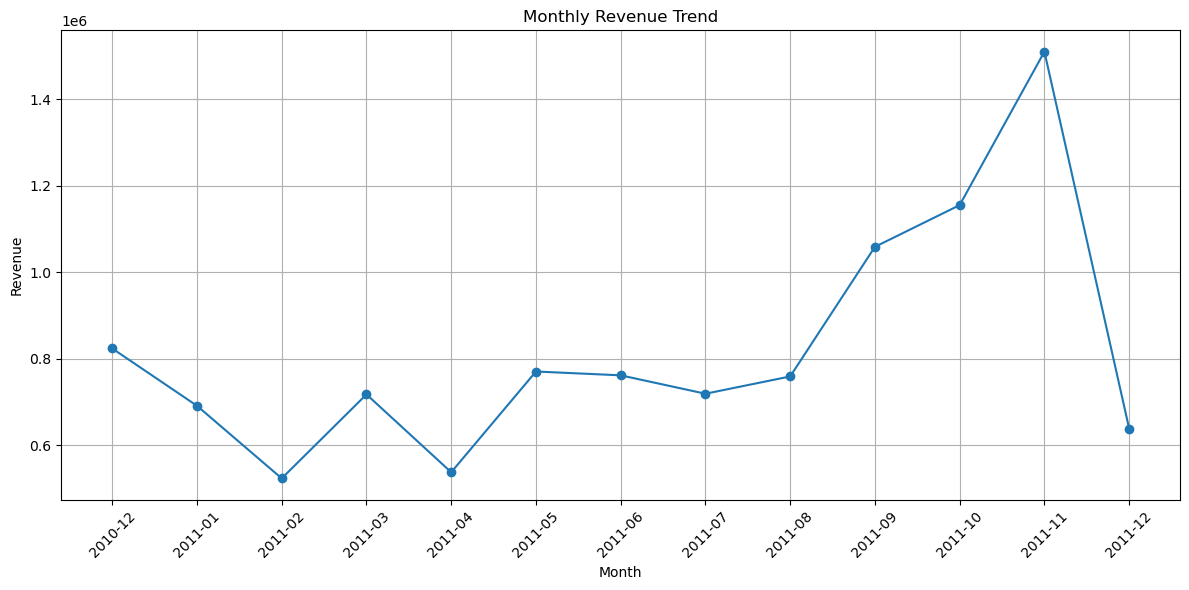

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64

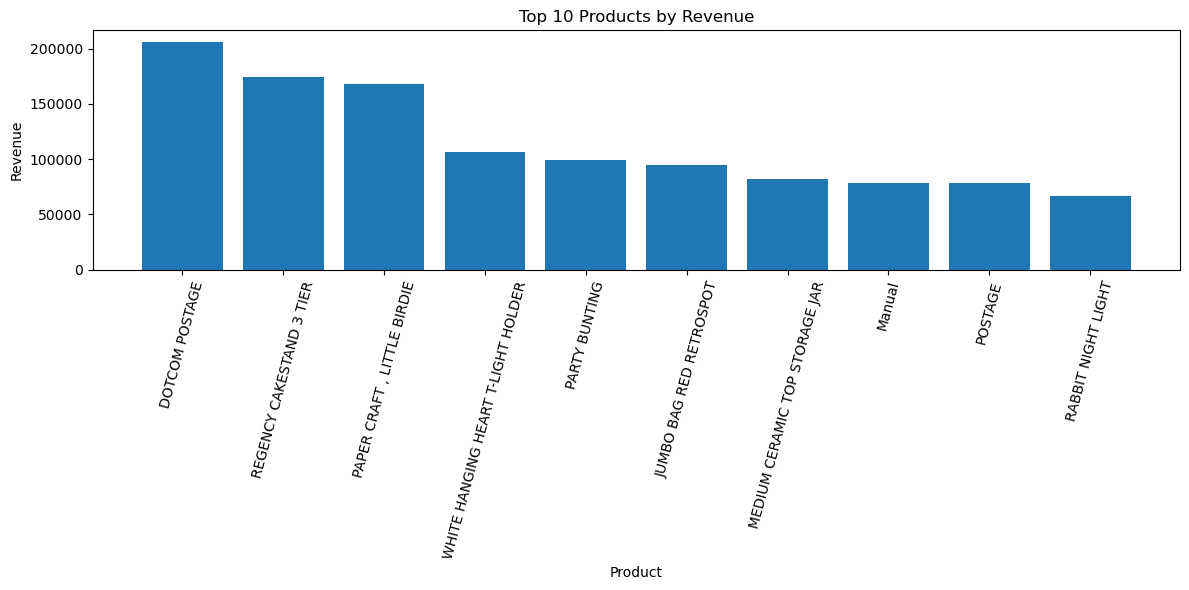

In [15]:
plt.figure(figsize=(12, 6))

plt.bar(top_products.index, top_products.values)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [16]:
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

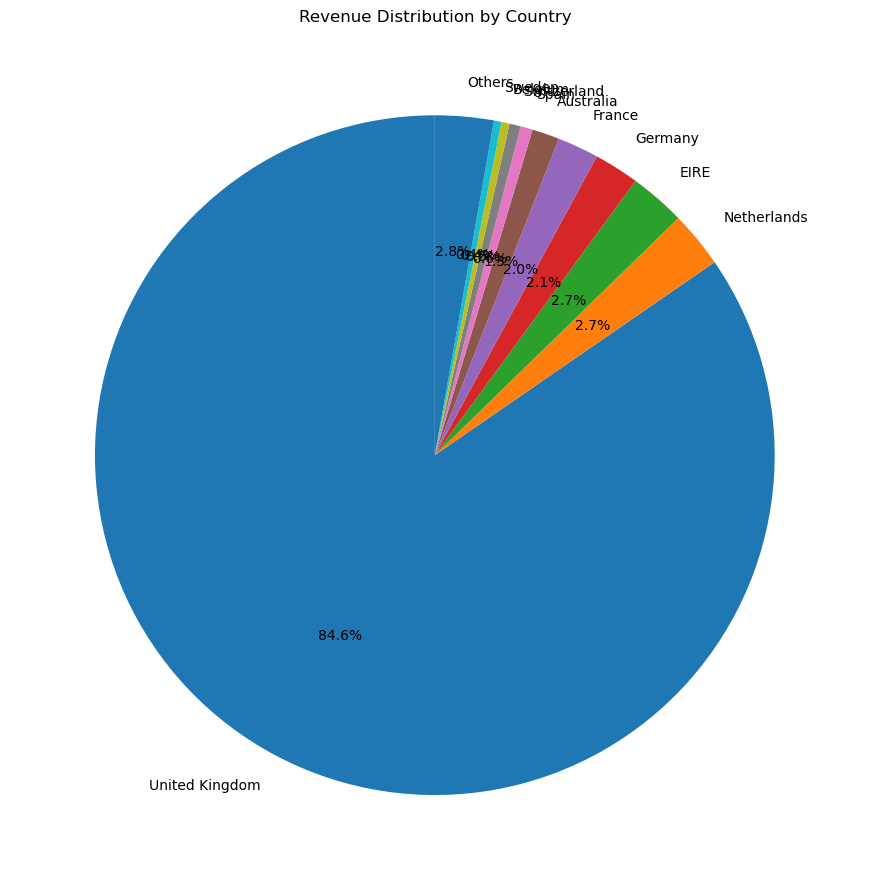

In [17]:
top_countries = country_revenue.head(10)

others = country_revenue.iloc[10:].sum()

pie_data = pd.concat([
    top_countries,
    pd.Series({'Others': others})
])

plt.figure(figsize=(9, 9))

plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Revenue Distribution by Country')
plt.tight_layout()
plt.show()

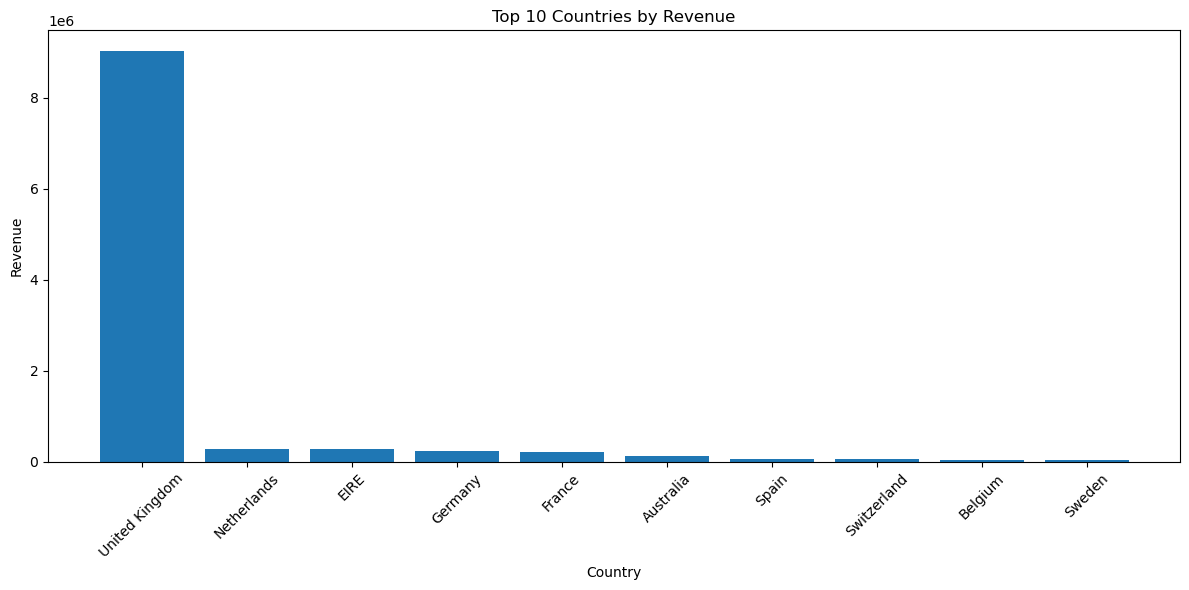

In [18]:
plt.figure(figsize=(12, 6))

plt.bar(top_countries.index, top_countries.values)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
monthly_data = df.copy()

monthly_data['Year'] = monthly_data['InvoiceDate'].dt.year
monthly_data['Month_Number'] = monthly_data['InvoiceDate'].dt.month

heatmap_data = monthly_data.pivot_table(
    values='Revenue',
    index='Year',
    columns='Month_Number',
    aggfunc='sum'
)

heatmap_data

Month_Number,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,823746.14
2011,691364.56,523631.89,717639.36,537808.621,770536.02,761739.9,719221.191,759138.38,1058590.172,1154979.3,1509496.33,638792.68


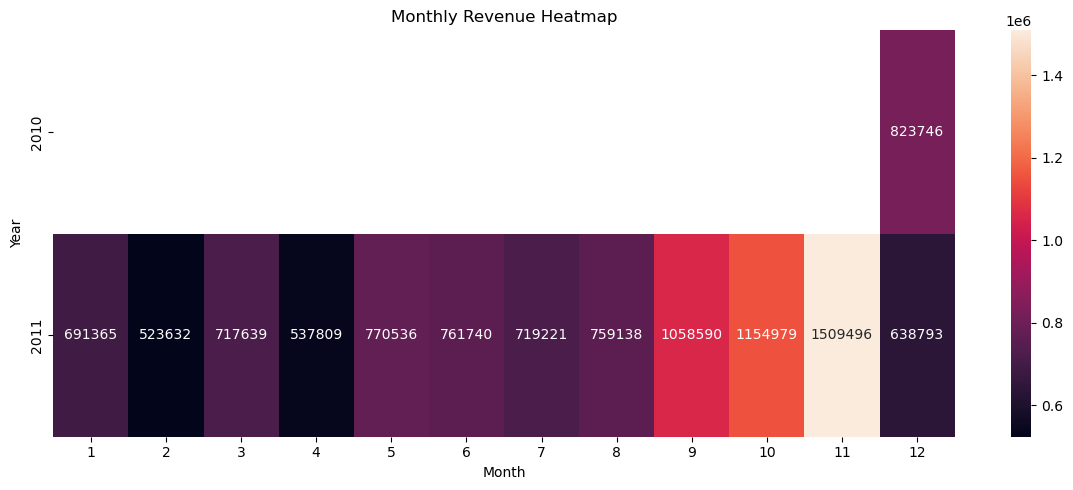

In [20]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f'
)

plt.title('Monthly Revenue Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')

plt.tight_layout()
plt.show()

In [21]:
monthly_quantity = df.groupby('Month')['Quantity'].sum()

monthly_quantity

Month
2010-12    359239
2011-01    387785
2011-02    283555
2011-03    377526
2011-04    308815
2011-05    395738
2011-06    389213
2011-07    401759
2011-08    421770
2011-09    570820
2011-10    623401
2011-11    754507
2011-12    314248
Name: Quantity, dtype: int64

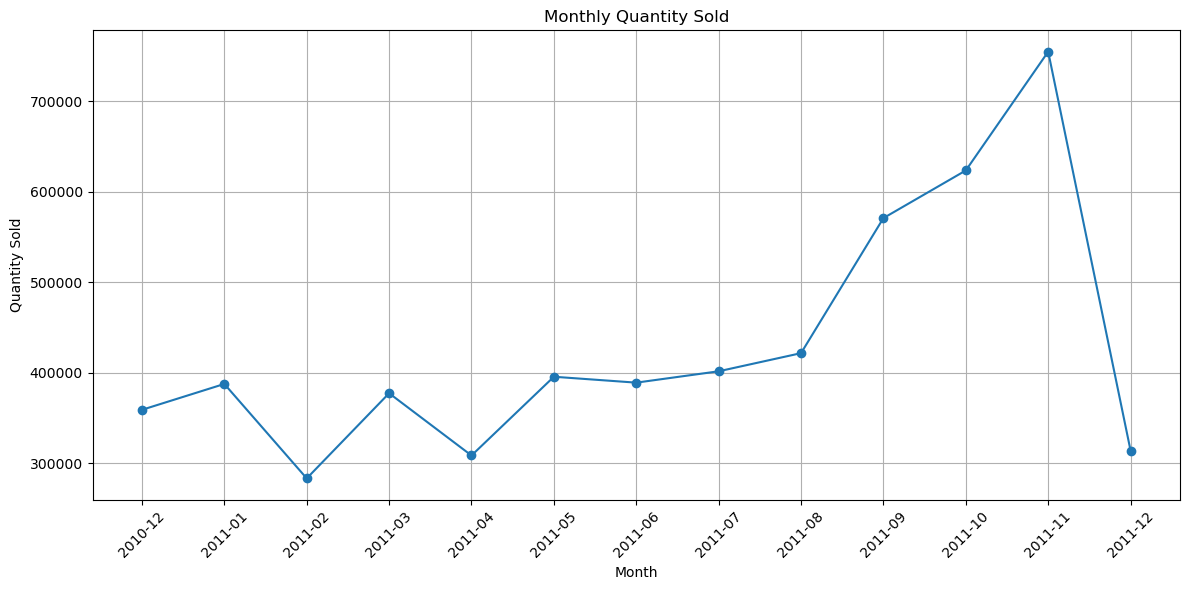

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_quantity.index,
    monthly_quantity.values,
    marker='o'
)

plt.title('Monthly Quantity Sold')
plt.xlabel('Month')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
print("Total Revenue: £", round(df['Revenue'].sum(), 2))
print("Total Quantity Sold:", df['Quantity'].sum())
print("Number of Transactions:", df['InvoiceNo'].nunique())
print("Number of Products:", df['Description'].nunique())
print("Number of Countries:", df['Country'].nunique())

Total Revenue: £ 10666684.54
Total Quantity Sold: 5588376
Number of Transactions: 19960
Number of Products: 4026
Number of Countries: 38


### Conclusion

This mini-project demonstrates how Python-based data visualization techniques can be used to analyze large-scale e-commerce transaction data. Data cleaning and preprocessing were performed before generating meaningful visualizations. The analysis provides insights into revenue trends, product performance, country-wise sales, and quantity sold. These techniques can help businesses understand customer purchasing patterns and make better data-driven decisions.